# Etapa 2A — Tres dinámicas con marginales idénticas (oracle)

Comparamos fases **estáticas**, **cíclicas** e **independientes** usando exactamente las mismas indicadoras centradas y las mismas frecuencias marginales de fase. Sólo cambia la dependencia entre `r_t` y `r_{t+1}`.

El operador relevante es el de esperanza condicional, `E[ψ(r_{t+1}) | r_t]`. En el subespacio centrado esperamos los espectros `{1,1,1}`, `{-1,i,-i}` y `{0,0,0}`. La condición independiente no permite predecir cada realización futura: su predicción óptima es la media condicional cero. Por eso evaluamos por separado el error contra muestras individuales y el error contra la media condicional.

Este notebook valida el **control oracle** de Etapa 2. No prueba todavía que un encoder neuronal recupere estos observables.

In [1]:
# ruff: noqa: E402, E501
import json
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

from koopman_jepa.koopman import (
    centered_phase_indicators,
    evaluate_phase_dynamics_oracle,
    linear_rollout,
    match_eigenvalues,
)

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
DYNAMICS = ("static", "cyclic", "independent")
LABELS = {"static": "Estática", "cyclic": "Cíclica", "independent": "Independiente"}
NUM_PHASES = 4
REPEATS_PER_TRANSITION = 64
TOLERANCE = 1e-10

results = {
    dynamics: evaluate_phase_dynamics_oracle(
        dynamics,
        repeats_per_transition=REPEATS_PER_TRANSITION,
        num_phases=NUM_PHASES,
    )
    for dynamics in DYNAMICS
}

summary = {
    dynamics: {
        key: result[key]
        for key in (
            "sample_count",
            "active_rank",
            "sample_prediction_error",
            "conditional_mean_error",
            "active_operator_error",
            "spectral_max_absolute_error",
        )
    }
    for dynamics, result in results.items()
}
print(json.dumps(summary, indent=2))

{
  "static": {
    "sample_count": 1024,
    "active_rank": 3,
    "sample_prediction_error": 3.1801640404177666e-15,
    "conditional_mean_error": 3.1729693642737025e-15,
    "active_operator_error": 2.8449451753175306e-15,
    "spectral_max_absolute_error": 3.3306690738754696e-15
  },
  "cyclic": {
    "sample_count": 1024,
    "active_rank": 3,
    "sample_prediction_error": 3.1801640404177666e-15,
    "conditional_mean_error": 3.1729693642737025e-15,
    "active_operator_error": 2.815971512229905e-15,
    "spectral_max_absolute_error": 2.220661586478539e-15
  },
  "independent": {
    "sample_count": 1024,
    "active_rank": 3,
    "sample_prediction_error": 1.0,
    "conditional_mean_error": 3.160938874629849e-16,
    "active_operator_error": 2.30565055498074e-16,
    "spectral_max_absolute_error": 1.6671596754778775e-16
  }
}


In [3]:
expected_count = NUM_PHASES**2 * REPEATS_PER_TRANSITION
expected_marginal_counts = np.repeat(NUM_PHASES * REPEATS_PER_TRANSITION, NUM_PHASES)
marginals_pass = all(
    result["sample_count"] == expected_count
    and np.array_equal(result["source_counts"], expected_marginal_counts)
    and np.array_equal(result["future_counts"], expected_marginal_counts)
    for result in results.values()
)
operator_pass = all(
    result["active_rank"] == NUM_PHASES - 1
    and result["conditional_mean_error"] < TOLERANCE
    and result["active_invariance_error"] < TOLERANCE
    and result["active_operator_error"] < TOLERANCE
    and result["spectral_max_absolute_error"] < TOLERANCE
    for result in results.values()
)
sample_error_pass = (
    results["static"]["sample_prediction_error"] < TOLERANCE
    and results["cyclic"]["sample_prediction_error"] < TOLERANCE
    and np.isclose(results["independent"]["sample_prediction_error"], 1.0)
)

initial = centered_phase_indicators(np.array([0]), NUM_PHASES)[0]
rollout_steps = np.arange(9)
rollout_errors = {}
for dynamics, result in results.items():
    rollout = linear_rollout(result["fitted_operator"], initial, steps=8)
    if dynamics == "static":
        truth = np.repeat(initial[None, :], len(rollout_steps), axis=0)
    elif dynamics == "cyclic":
        truth = centered_phase_indicators(rollout_steps % NUM_PHASES, NUM_PHASES)
    else:
        truth = np.vstack([initial, np.zeros((8, NUM_PHASES))])
    rollout_errors[dynamics] = np.linalg.norm(rollout - truth, axis=1)

rollout_pass = all(errors[1:].max() < TOLERANCE for errors in rollout_errors.values())
oracle_gate_passed = bool(marginals_pass and operator_pass and sample_error_pass and rollout_pass)
gate = {
    "identical_marginals": bool(marginals_pass),
    "conditional_operators": bool(operator_pass),
    "sample_error_semantics": bool(sample_error_pass),
    "eight_step_conditional_rollouts": bool(rollout_pass),
    "oracle_gate_passed": oracle_gate_passed,
}
print(json.dumps(gate, indent=2))
assert oracle_gate_passed

{
  "identical_marginals": true,
  "conditional_operators": true,
  "sample_error_semantics": true,
  "eight_step_conditional_rollouts": true,
  "oracle_gate_passed": true
}


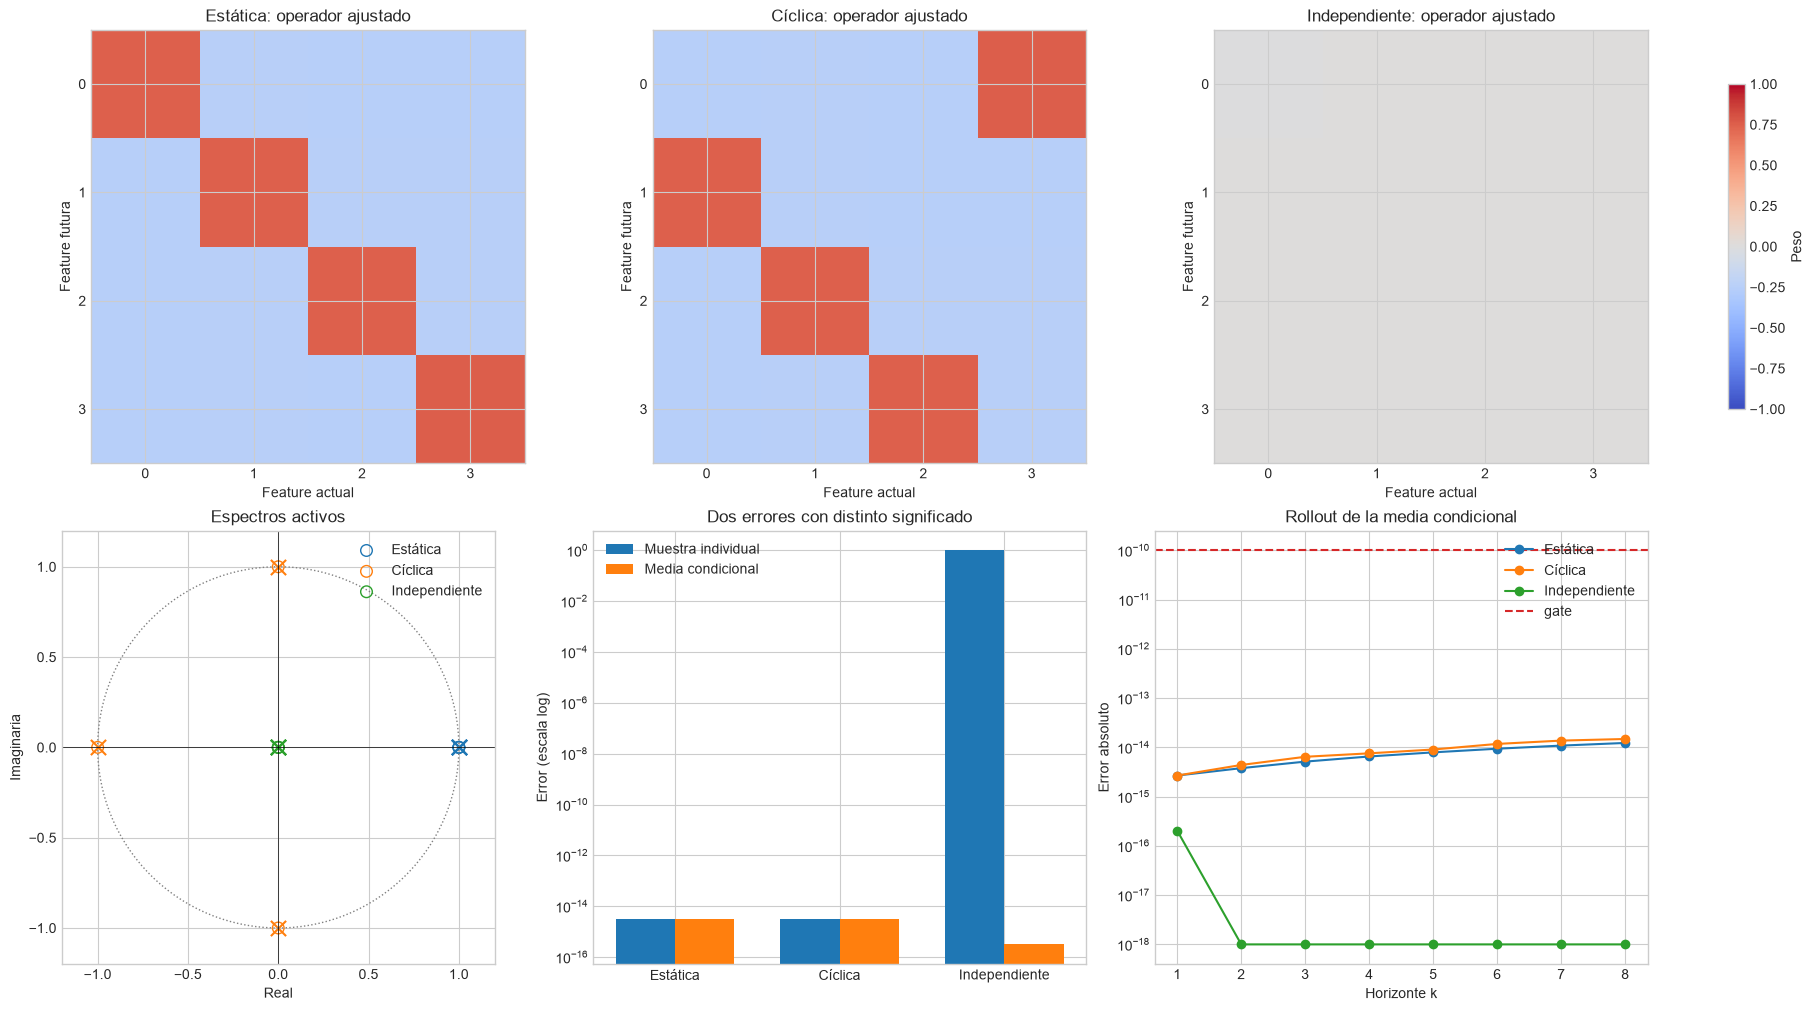

## Análisis del resultado

- Gate oracle de Etapa 2A: **PASS**.
- Cada condición contiene **1024 transiciones** y conteos marginales idénticos de **256** por fase, tanto en origen como en destino.
- Espectro estimado estático: `['+1.00+0.00i', '+1.00+0.00i', '+1.00+0.00i']`.
- Espectro estimado cíclico: `['+0.00+1.00i', '+0.00-1.00i', '-1.00+0.00i']`.
- Espectro estimado independiente: `['-0.00+0.00i', '+0.00+0.00i', '+0.00+0.00i']`.
- Máximo error espectral: **3.33e-15**.
- En la condición independiente, error contra una realización: **1.00**; error contra su media condicional: **3.16e-16**.
- Máximo error de rollout condicional a ocho pasos: **1.48e-14**.

Las distribuciones marginales no distinguen las condiciones: las tres visitan cada fase con la misma frecuencia. Lo que cambia es la dependencia temporal, y esa diferencia aparece directamente en el operador condicional: identidad para la estática, rotación de orden cuatro para la cíclica y contracción inmediata a cero para la independiente.

El error por muestra igual a 1 en la condición independiente **no es un fallo**. Es la incertidumbre irreducible de una fase futura uniforme. El operador de Koopman estocástico predice la esperanza condicional, que sí se recupera con error numérico.

Este PASS valida el dataset balanceado, la semántica estocástica, los espectros y los rollouts del oracle. El próximo paso es generar observaciones de ventana con estas mismas fases y luego comprobar si un encoder puede aprender el subespacio sin recibir las indicadoras verdaderas.


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for axis, dynamics in zip(axes[0], DYNAMICS, strict=True):
    image = axis.imshow(results[dynamics]["fitted_operator"], cmap="coolwarm", vmin=-1, vmax=1)
    axis.set(title=f"{LABELS[dynamics]}: operador ajustado", xlabel="Feature actual", ylabel="Feature futura")
    axis.set_xticks(range(NUM_PHASES))
    axis.set_yticks(range(NUM_PHASES))
fig.colorbar(image, ax=axes[0].tolist(), shrink=0.75, label="Peso")

colors = {"static": "tab:blue", "cyclic": "tab:orange", "independent": "tab:green"}
for dynamics in DYNAMICS:
    result = results[dynamics]
    matched = match_eigenvalues(result["estimated_spectrum"], result["expected_spectrum"])
    axes[1, 0].scatter(matched["expected"].real, matched["expected"].imag, marker="x", s=120, color=colors[dynamics])
    axes[1, 0].scatter(matched["estimated"].real, matched["estimated"].imag, facecolors="none", edgecolors=colors[dynamics], s=70, label=LABELS[dynamics])
unit_circle = plt.Circle((0, 0), 1, fill=False, linestyle=":", color="gray")
axes[1, 0].add_patch(unit_circle)
axes[1, 0].axhline(0, color="black", linewidth=0.5)
axes[1, 0].axvline(0, color="black", linewidth=0.5)
axes[1, 0].set(title="Espectros activos", xlabel="Real", ylabel="Imaginaria", aspect="equal", xlim=(-1.2, 1.2), ylim=(-1.2, 1.2))
axes[1, 0].legend()

x = np.arange(len(DYNAMICS))
sample_errors = [results[d]["sample_prediction_error"] for d in DYNAMICS]
conditional_errors = [results[d]["conditional_mean_error"] for d in DYNAMICS]
axes[1, 1].bar(x - 0.18, np.maximum(sample_errors, 1e-18), 0.36, label="Muestra individual")
axes[1, 1].bar(x + 0.18, np.maximum(conditional_errors, 1e-18), 0.36, label="Media condicional")
axes[1, 1].set(title="Dos errores con distinto significado", ylabel="Error (escala log)", xticks=x, xticklabels=[LABELS[d] for d in DYNAMICS], yscale="log")
axes[1, 1].legend()

for dynamics in DYNAMICS:
    axes[1, 2].semilogy(rollout_steps[1:], np.maximum(rollout_errors[dynamics][1:], 1e-18), marker="o", label=LABELS[dynamics], color=colors[dynamics])
axes[1, 2].axhline(TOLERANCE, color="tab:red", linestyle="--", label="gate")
axes[1, 2].set(title="Rollout de la media condicional", xlabel="Horizonte k", ylabel="Error absoluto")
axes[1, 2].legend()
plt.show()

spectra_text = {
    dynamics: [f"{value.real:+.2f}{value.imag:+.2f}i" for value in results[dynamics]["estimated_spectrum"]]
    for dynamics in DYNAMICS
}
display(Markdown(f"""## Análisis del resultado

- Gate oracle de Etapa 2A: **{'PASS' if oracle_gate_passed else 'FAIL'}**.
- Cada condición contiene **{expected_count} transiciones** y conteos marginales idénticos de **{expected_marginal_counts[0]}** por fase, tanto en origen como en destino.
- Espectro estimado estático: `{spectra_text['static']}`.
- Espectro estimado cíclico: `{spectra_text['cyclic']}`.
- Espectro estimado independiente: `{spectra_text['independent']}`.
- Máximo error espectral: **{max(results[d]['spectral_max_absolute_error'] for d in DYNAMICS):.2e}**.
- En la condición independiente, error contra una realización: **{results['independent']['sample_prediction_error']:.2f}**; error contra su media condicional: **{results['independent']['conditional_mean_error']:.2e}**.
- Máximo error de rollout condicional a ocho pasos: **{max(errors[1:].max() for errors in rollout_errors.values()):.2e}**.

Las distribuciones marginales no distinguen las condiciones: las tres visitan cada fase con la misma frecuencia. Lo que cambia es la dependencia temporal, y esa diferencia aparece directamente en el operador condicional: identidad para la estática, rotación de orden cuatro para la cíclica y contracción inmediata a cero para la independiente.

El error por muestra igual a 1 en la condición independiente **no es un fallo**. Es la incertidumbre irreducible de una fase futura uniforme. El operador de Koopman estocástico predice la esperanza condicional, que sí se recupera con error numérico.

Este PASS valida el dataset balanceado, la semántica estocástica, los espectros y los rollouts del oracle. El próximo paso es generar observaciones de ventana con estas mismas fases y luego comprobar si un encoder puede aprender el subespacio sin recibir las indicadoras verdaderas.
"""))